In [1]:
import torch.nn as nn
from black_scholes.sobolev.bs_sobolev_nd import BlackScholesSobolevMultiAsset
from utility.model import EarlyStopping, ModelConfig
from config.bs_sobolev_nd import *

In [2]:
seeds = [42]
for seed in seeds:
    print(f'Training model with seed {seed}...')
    model = BlackScholesSobolevMultiAsset(model_config, seed=seed)
    model.set_params(K, r, sigmas, corr, T, S_mins, S_maxs)
    model.set_loss_weights(loss_weights)
    # early_stopping = EarlyStopping(patience=1000, min_delta=1e-7)
    early_stopping = None
    model.train(batch_size=4096, epochs=30000, early_stopping=early_stopping, anneal_freq=1000, alpha=0.9)
    model.save(f'../../models/bs_sobolev_nd/{seed}.pth')

Training model with seed 42...
Iter      0 | Train: 1.3461e+00 | Val: 1.3580e+00 | Weights: pde=0.250  J2=0.417  J3=0.250  J4=0.083
Iter    500 | Train: 1.2765e-02 | Val: 1.6366e-02 | Weights: pde=0.250  J2=0.417  J3=0.250  J4=0.083
Iter   1000 | Train: 8.8804e-03 | Val: 1.3864e-02 | Weights: pde=0.250  J2=0.417  J3=0.250  J4=0.083
Iter   1500 | Train: 5.7806e-03 | Val: 1.1235e-02 | Weights: pde=0.250  J2=0.417  J3=0.250  J4=0.083
Iter   2000 | Train: 4.6367e-03 | Val: 8.9183e-03 | Weights: pde=0.250  J2=0.417  J3=0.250  J4=0.083
Iter   2500 | Train: 5.3281e-03 | Val: 1.0203e-02 | Weights: pde=0.250  J2=0.417  J3=0.250  J4=0.083
Iter   3000 | Train: 4.4783e-03 | Val: 8.2378e-03 | Weights: pde=0.583  J2=0.174  J3=0.160  J4=0.083
Iter   3500 | Train: 3.1686e-03 | Val: 6.8265e-03 | Weights: pde=0.583  J2=0.174  J3=0.160  J4=0.083
Iter   4000 | Train: 4.3726e-03 | Val: 6.6118e-03 | Weights: pde=0.294  J2=0.241  J3=0.382  J4=0.083
Iter   4500 | Train: 4.5358e-03 | Val: 7.5317e-03 | Weights:

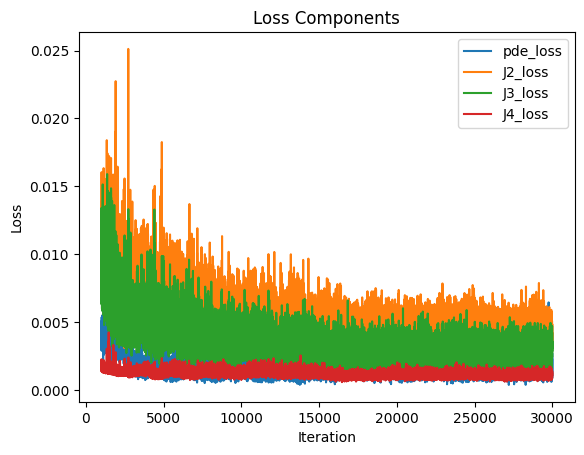

In [3]:
model.plot_losses(detailed=True, start_epoch=1000)